# Amazon Review Sentiment Analysis


## 1. Data Cleaning

In [ ]:
!pip install -q wordcloud

In [7]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

df = pd.read_csv(r'C:\Users\Admin\OneDrive\Desktop\Data Science ExcelR\Assignments\Assignment 19\amazonreviews.tsv', sep='\t')
print('Shape:', df.shape)
print(df['label'].value_counts())
print('Missing values:\n', df.isnull().sum())

ModuleNotFoundError: No module named 'wordcloud'

In [8]:
# Remove missing reviews and duplicates
df = df.dropna(subset=['review', 'label'])
df = df.drop_duplicates(subset=['review']).reset_index(drop=True)
print('After cleaning:', df.shape)

After cleaning: (10000, 3)


In [9]:
stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)          # keep letters only
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['clean_review'] = df['review'].apply(clean_text)
df[['review', 'clean_review']].head(3)

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning non gamer sound track beautiful paints...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack reading lot reviews saying bes...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...


## 2. Exploratory Analysis

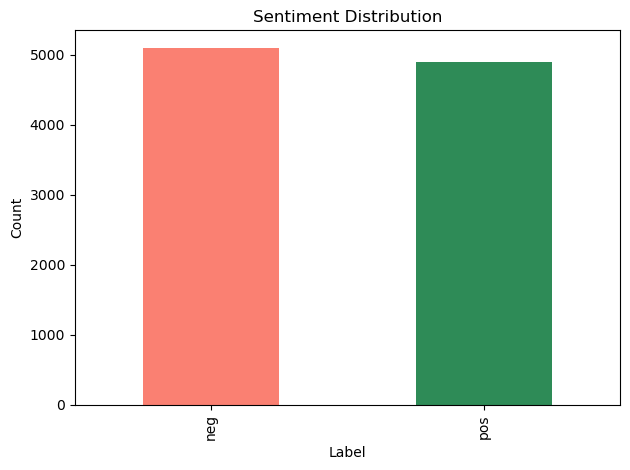

In [5]:
df['label'].value_counts().plot(kind='bar', color=['salmon', 'seagreen'])
plt.title('Sentiment Distribution')
plt.xlabel('Label'); plt.ylabel('Count')
plt.tight_layout()
plt.show()

NameError: name 'WordCloud' is not defined

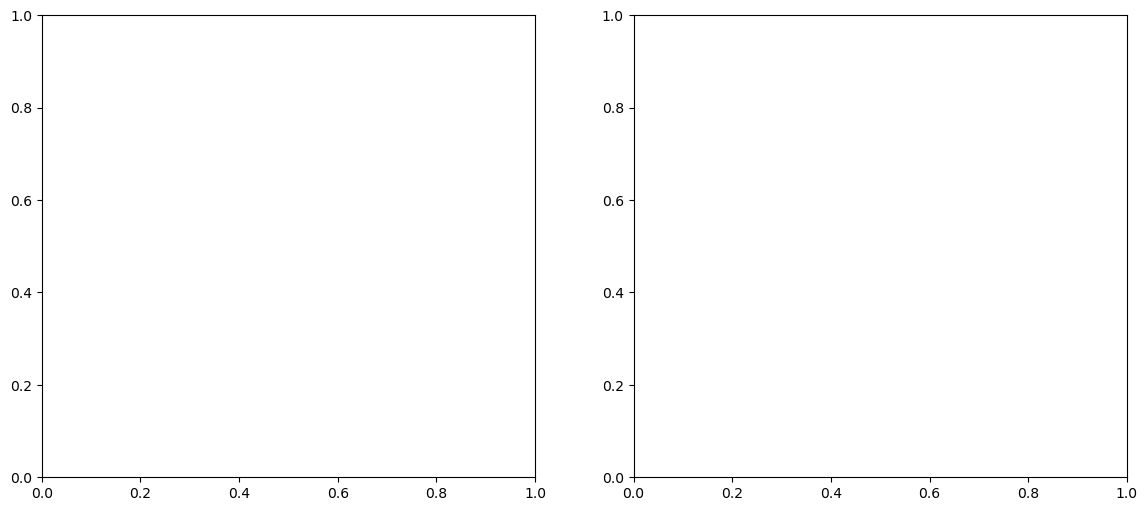

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pos_text = ' '.join(df[df['label'] == 'pos']['clean_review'])
neg_text = ' '.join(df[df['label'] == 'neg']['clean_review'])

WordCloud(width=600, height=400, background_color='white').generate(pos_text)
axes[0].imshow(WordCloud(width=600, height=400, background_color='white').generate(pos_text))
axes[0].set_title('Positive Reviews'); axes[0].axis('off')

axes[1].imshow(WordCloud(width=600, height=400, background_color='white').generate(neg_text))
axes[1].set_title('Negative Reviews'); axes[1].axis('off')

plt.tight_layout()
plt.show()

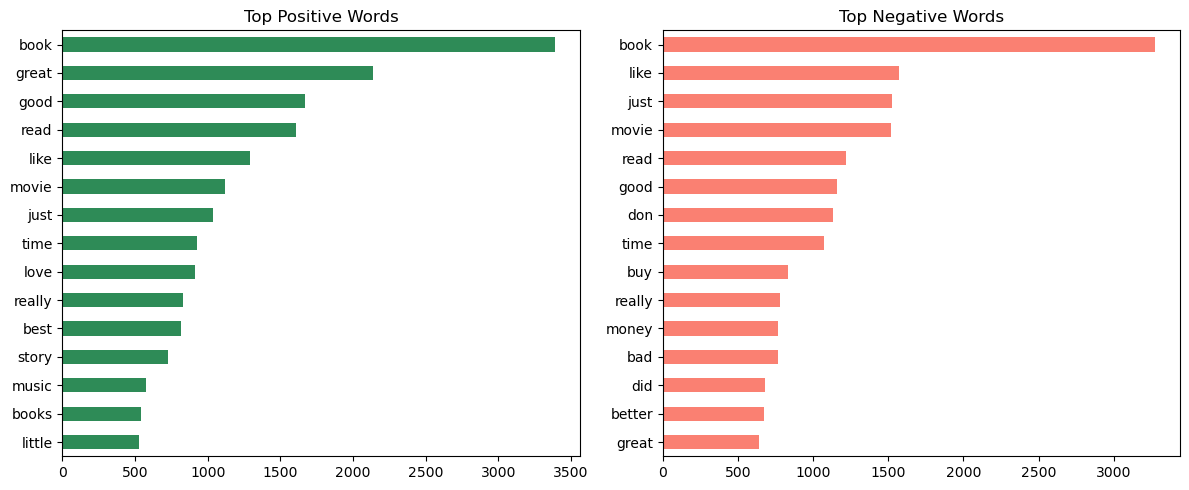

In [11]:
def top_words(text_series, n=15):
    cv = CountVectorizer(max_features=n)
    matrix = cv.fit_transform(text_series)
    counts = matrix.sum(axis=0).A1
    return pd.Series(counts, index=cv.get_feature_names_out()).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
top_words(df[df['label']=='pos']['clean_review']).plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('Top Positive Words'); axes[0].invert_yaxis()
top_words(df[df['label']=='neg']['clean_review']).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Top Negative Words'); axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

**Observations:** Classes are reasonably balanced (~51% negative / 49% positive). Positive reviews are dominated by praise words (*great*, *love*, *best*), while negative reviews surface complaint-related terms. This separability is a good sign for a bag-of-words/TF-IDF based classifier.

## 3. Model Development

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(X_train_tfidf.shape, X_test_tfidf.shape)

(8000, 5000) (2000, 5000)


In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear SVM': LinearSVC(),
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)

## 4. Validation

In [16]:
results = []
for name, model in models.items():
    # 5-fold cross-validation on the training set
    cv_scores = cross_val_score(model, X_train_tfidf, y_train, cv=5, scoring='accuracy')

    pred = model.predict(X_test_tfidf)
    results.append({
        'Model': name,
        'CV Accuracy (mean)': cv_scores.mean(),
        'Test Accuracy': accuracy_score(y_test, pred),
        'Test F1-score': f1_score(y_test, pred, pos_label='pos'),
    })

results_df = pd.DataFrame(results)
results_df

,Model,CV Accuracy (mean),Test Accuracy,Test F1-score
0,Logistic Regression,0.852875,0.8505,0.846272
1,Linear SVM,0.836750,0.8390,0.837209


In [17]:
best_name = results_df.sort_values('Test F1-score', ascending=False).iloc[0]['Model']
best_model = models[best_name]
y_pred = best_model.predict(X_test_tfidf)

print(f'Classification report — {best_name}\n')
print(classification_report(y_test, y_pred))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred, labels=['pos', 'neg']))

Classification report — Logistic Regression

              precision    recall  f1-score   support

         neg       0.85      0.86      0.85      1019
         pos       0.85      0.84      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Confusion matrix:
 [[823 158]
 [141 878]]


## Report Summary

- **Preprocessing:** lowercased text, stripped punctuation/digits, removed stopwords and very short tokens; no missing values or duplicate reviews were present after cleaning.
- **EDA:** classes are close to balanced; word clouds and top-word frequency plots confirm clear vocabulary separation between positive and negative reviews (e.g. "great/love/best" vs. complaint terms), supporting a bag-of-words approach.
- **Modeling:** TF-IDF (unigrams + bigrams, 5000 features) fed into Logistic Regression and Linear SVM — both strong, fast baselines for text classification.
- **Validation:** 5-fold cross-validation on the training set and held-out test accuracy/F1 are reported in the results table; the better-performing model's full classification report and confusion matrix are shown above.
- **Business impact:** this classifier can flag negative reviews in near real-time, even when a review's star rating doesn't match its tone, helping the team spot problem products faster.
- **Next steps:** richer embeddings (Word2Vec, BERT) or class-imbalance-aware thresholds could push performance further, and per-product aggregation of predicted sentiment would directly support the "spike in negative feedback" monitoring use case.